In [1]:
import time
from importlib.metadata import version

import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats("svg")

import equinox as eqx
import jax
import jax.numpy as jnp
import jax.random as jr
import numpy as np
import optax
from scipy.integrate import cumulative_trapezoid

jax.config.update("jax_enable_x64", False)

In [2]:
# BOOK_FIGURE_STYLE_CELL
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

try:
    import seaborn as sns
except ImportError:
    sns = None

try:
    import matplotlib_inline

    matplotlib_inline.backend_inline.set_matplotlib_formats("svg")
except Exception:
    matplotlib_inline = None

FIGURE_SIZES = {
    "full_landscape": (7.35, 4.40),
    "full_standard": (7.35, 4.90),
    "full_tall": (7.35, 5.50),
    "half_standard": (3.55, 2.55),
    "half_tall": (3.55, 3.05),
    "inset": (2.30, 1.75),
}

BOOK_COLORS = {
    "blue": "#4C78A8",
    "orange": "#F58518",
    "green": "#54A24B",
    "red": "#E45756",
    "gray": "#7F7F7F",
}

BOOK_TARGET = "web"


def setup_book_style(target="web"):
    global BOOK_TARGET
    BOOK_TARGET = target
    mpl.rcParams.update(
        {
            "figure.figsize": FIGURE_SIZES["half_standard"],
            "figure.dpi": 120,
            "savefig.dpi": 300,
            "savefig.bbox": "tight",
            "savefig.pad_inches": 0.02,
            "font.family": "sans-serif",
            "font.sans-serif": ["DejaVu Sans", "Arial", "Liberation Sans"],
            "axes.labelsize": 9,
            "axes.titlesize": 9,
            "axes.linewidth": 0.8,
            "axes.grid": False,
            "axes.spines.top": False,
            "axes.spines.right": False,
            "xtick.labelsize": 8,
            "ytick.labelsize": 8,
            "xtick.major.width": 0.8,
            "ytick.major.width": 0.8,
            "legend.fontsize": 8,
            "legend.frameon": False,
            "lines.linewidth": 1.5,
            "lines.markersize": 4,
            "patch.linewidth": 0.8,
            "image.cmap": "viridis",
        }
    )
    if target == "latex":
        try:
            mpl.rcParams["text.usetex"] = False
        except Exception:
            mpl.rcParams["text.usetex"] = False


def new_figure(
    size="half_standard",
    nrows=1,
    ncols=1,
    sharex=False,
    sharey=False,
    constrained=True,
    squeeze=True,
    **kwargs,
):
    fig, ax = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        sharex=sharex,
        sharey=sharey,
        constrained_layout=constrained,
        figsize=FIGURE_SIZES[size],
        squeeze=squeeze,
        **kwargs,
    )
    return fig, ax


def label_panels(axes=None, labels=None, x=0.02, y=0.98, **kwargs):
    if axes is None:
        axes = plt.gcf().axes
    axes = np.atleast_1d(axes).ravel()
    if labels is None:
        labels = [f"({chr(97 + i)})" for i in range(len(axes))]
    default = dict(
        fontsize=9,
        fontweight="bold",
        va="top",
        ha="left",
        transform=None,
    )
    default.update(kwargs)
    for ax, label in zip(axes, labels):
        call_kwargs = dict(default)
        if call_kwargs["transform"] is None:
            call_kwargs["transform"] = ax.transAxes
        ax.text(x, y, label, **call_kwargs)


def finalize_axes(axes=None, keep_box=False, grid=False):
    if axes is None:
        axes = plt.gcf().axes
    axes = np.atleast_1d(axes).ravel()
    for ax in axes:
        if grid:
            ax.grid(axis="y", color="0.88", linewidth=0.6)
        else:
            ax.grid(False)
        for spine in ax.spines.values():
            spine.set_linewidth(0.8)
        if keep_box:
            ax.spines["top"].set_visible(True)
            ax.spines["right"].set_visible(True)
        else:
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
    return axes


def save_book_figure(fig, basename, target="web", pdf=True, png=False):
    base = Path(basename)
    base.parent.mkdir(parents=True, exist_ok=True)
    if pdf:
        fig.savefig(base.with_suffix(".pdf"), bbox_inches="tight", pad_inches=0.02)
    if png:
        fig.savefig(base.with_suffix(".png"), bbox_inches="tight", pad_inches=0.02)


setup_book_style(target="web")


# DeepONet in JAX

DeepONet is a neural architecture for learning operators: maps whose inputs and outputs are functions. Here we construct a DeepONet for the antiderivative operator

$$
\mathcal{G}^{\dagger}:\mathcal{A}\to\mathcal{U},
\qquad
\big[\mathcal{G}^{\dagger}(a)\big](y)=\int_0^y a(s)\,\mathrm{d}s.
$$

The companion notebook implements the architecture independently. Its benchmark family follows {cite:t}`lu2021learning` and the archived DeepONet software {cite:p}`lu2020deeponetrepo`. The experiment is intentionally small: it illustrates the branch--trunk construction and measures generalization to held-out input functions under one fixed discretization and input distribution.

For the broader operator-learning setting, see Section {ref}`sec-hup-op-01-reading` and the earlier discussion of function-valued inputs in Section {ref}`sec-hup-funcin-01-functional-inputs`.

## The DeepONet construction

Let $\mathcal{A}=\mathcal{U}=C([0,1])$. The reference operator $\mathcal{G}^{\dagger}:\mathcal{A}\to\mathcal{U}$ maps an input function $a$ to its antiderivative. A computer observes $a$ only at fixed sensor locations $X=(x_1,\ldots,x_m)$, through the encoder

$$
P_Xa=\big(a(x_1),\ldots,a(x_m)\big)\in\mathbb{R}^m.
$$

A DeepONet combines two neural networks:

- a **branch network** $B_{\theta}:\mathbb{R}^m\to\mathbb{R}^p$, which encodes $P_Xa$;
- a **trunk network** $T_{\theta}:[0,1]\to\mathbb{R}^p$, which encodes the query location $y$.

With a scalar bias $c_{\theta}$, the learned operator is

$$
\big[\mathcal{G}_{\theta}(a)\big](y)
=B_{\theta}(P_Xa)^{\mathsf T}T_{\theta}(y)+c_{\theta}.
$$

The training examples are triples

$$
\left(P_Xa_i,\;y_{ij},\;\big[\mathcal{G}^{\dagger}(a_i)\big](y_{ij})\right).
$$

One input function can therefore provide many examples, one for each query point. The model depends on $a$ only through $P_Xa$; two functions with identical sensor values are indistinguishable to this architecture.

## Benchmark provenance and scope

The archived DeepONet v1.0.0 software is identified by digital object identifier (DOI) `10.5281/zenodo.4319385` and Git commit `bb38685` {cite:p}`lu2020deeponetrepo`. Its antiderivative benchmark uses a mean-zero Gaussian random field with a squared-exponential (RBF) covariance kernel of length scale $0.2$ and $100$ fixed sensors. We retain those choices but use smaller data splits, a shorter optimization run, and an independent JAX/Equinox implementation. Unlike the archived implementation, which samples on a denser internal grid and interpolates to the sensor locations, we sample the finite covariance matrix directly on the sensor grid and form targets by trapezoidal quadrature.

```{only} html
The notebook does not download or copy the reference source. Its checked outputs are regenerated with the version-pinned JAX stack in `book/requirements-gpjax.txt` by running `scripts/run_gpjax_notebook.sh book/hup/op/02_deeponet.ipynb` from the repository root.
```

In [3]:
environment = {
    name: version(name)
    for name in ("jax", "jaxlib", "equinox", "optax", "numpy", "scipy", "matplotlib")
}
environment["device"] = jax.devices()[0].platform
environment

{'jax': '0.11.1',
 'jaxlib': '0.11.1',
 'equinox': '0.13.8',
 'optax': '0.2.8',
 'numpy': '2.5.1',
 'scipy': '1.18.0',
 'matplotlib': '3.11.0',
 'device': 'cpu'}

## A finite-dimensional experiment

We sample each input on the same $100$-point grid used for the branch sensors, numerical integration, and output queries. The target $\mathcal{G}^{\dagger}_h$ is the cumulative trapezoidal approximation on that grid. Thus this experiment learns a discretized map under a specified input law; it does not establish approximation of the continuum operator.

For a sampled input $a_i$, each supervised example has the form

$$
\left(P_Xa_i,\;y_{ij}\right)
\longmapsto
\big[\mathcal{G}^{\dagger}_h(a_i)\big](y_{ij}).
$$

The training, validation, and test sets contain independent input functions. Validation data monitor optimization; the test functions remain untouched until the final evaluation. The first figure below shows two sampled inputs and their discrete antiderivatives.

In [4]:
def rbf_covariance(xs, length_scale, jitter=1e-10):
    distances = xs[:, None] - xs[None, :]
    cov = np.exp(-0.5 * (distances / length_scale) ** 2)
    return cov + jitter * np.eye(len(xs))


def sample_grf_inputs(num_functions, grid, length_scale, rng):
    chol = np.linalg.cholesky(rbf_covariance(grid, length_scale))
    standard_normals = rng.standard_normal((num_functions, len(grid)))
    return standard_normals @ chol.T


def antiderivative_values(inputs, grid):
    return cumulative_trapezoid(inputs, grid, axis=1, initial=0.0)


def make_query_pairs(inputs, outputs, grid, queries_per_function, rng):
    num_functions, num_grid_points = inputs.shape
    query_ids = rng.integers(
        0, num_grid_points, size=(num_functions, queries_per_function)
    )
    branch_inputs = np.repeat(inputs, queries_per_function, axis=0)
    query_locations = grid[query_ids].reshape(-1, 1)
    targets = np.take_along_axis(outputs, query_ids, axis=1).reshape(-1, 1)
    return tuple(
        array.astype(np.float32)
        for array in (branch_inputs, query_locations, targets)
    )


def make_grid_pairs(inputs, outputs, grid):
    num_functions, num_grid_points = inputs.shape
    branch_inputs = np.repeat(inputs, num_grid_points, axis=0)
    query_locations = np.tile(grid, num_functions).reshape(-1, 1)
    targets = outputs.reshape(-1, 1)
    return tuple(
        array.astype(np.float32)
        for array in (branch_inputs, query_locations, targets)
    )


num_sensors = 100
sensor_grid = np.linspace(0.0, 1.0, num_sensors, dtype=np.float64)
length_scale = 0.2
num_train_functions = 256
num_validation_functions = 64
num_test_functions = 64
queries_per_train_function = 32

seed_sequence = np.random.SeedSequence(1234)
rng_train, rng_validation, rng_test, rng_queries = [
    np.random.default_rng(seed) for seed in seed_sequence.spawn(4)
]

a_train = sample_grf_inputs(
    num_train_functions, sensor_grid, length_scale, rng_train
)
a_validation = sample_grf_inputs(
    num_validation_functions, sensor_grid, length_scale, rng_validation
)
a_test = sample_grf_inputs(
    num_test_functions, sensor_grid, length_scale, rng_test
)

g_train_functions = antiderivative_values(a_train, sensor_grid)
g_validation_functions = antiderivative_values(a_validation, sensor_grid)
g_test_functions = antiderivative_values(a_test, sensor_grid)

Xb_train, Yq_train, target_train = make_query_pairs(
    a_train,
    g_train_functions,
    sensor_grid,
    queries_per_train_function,
    rng_queries,
)
Xb_train_grid, Yq_train_grid, target_train_grid = make_grid_pairs(
    a_train, g_train_functions, sensor_grid
)
Xb_validation, Yq_validation, target_validation = make_grid_pairs(
    a_validation, g_validation_functions, sensor_grid
)
print("training triples:", Xb_train.shape[0])
print("training functions:", len(a_train))
print("validation functions:", len(a_validation))
print("test functions:", len(a_test))

training triples: 8192
training functions: 256
validation functions: 64
test functions: 64


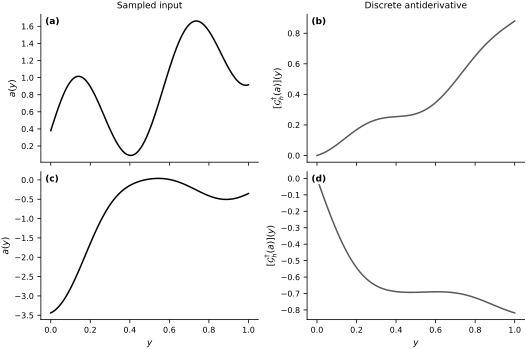

In [5]:
fig, axes = new_figure(
    "full_standard", nrows=2, ncols=2, sharex=True, constrained=True
)
for row in range(2):
    axes[row, 0].plot(sensor_grid, a_train[row], color="black")
    axes[row, 0].set_ylabel(r"$a(y)$")
    axes[row, 1].plot(sensor_grid, g_train_functions[row], color="0.35")
    axes[row, 1].set_ylabel(r"$[\mathcal{G}^{\dagger}_h(a)](y)$")
axes[0, 0].set_title("Sampled input")
axes[0, 1].set_title("Discrete antiderivative")
for ax in axes[-1, :]:
    ax.set_xlabel(r"$y$")
label_panels(axes, bbox=dict(facecolor="white", edgecolor="none", alpha=0.85, pad=0.6))
finalize_axes(axes);

## JAX implementation

The branch and trunk networks are multilayer perceptrons with the same latent dimension $p$. Their dot product produces a scalar prediction at one query location. We use a deliberately modest architecture because the purpose is to expose the construction and the evaluation protocol, not to optimize the benchmark score.

In [6]:
class DeepONet(eqx.Module):
    branch: eqx.nn.MLP
    trunk: eqx.nn.MLP
    bias: jnp.ndarray

    def __init__(self, branch_dim, latent_dim, width, depth, *, key):
        key_branch, key_trunk = jr.split(key, 2)
        self.branch = eqx.nn.MLP(
            in_size=branch_dim,
            out_size=latent_dim,
            width_size=width,
            depth=depth,
            activation=jax.nn.relu,
            final_activation=lambda x: x,
            key=key_branch,
        )
        self.trunk = eqx.nn.MLP(
            in_size=1,
            out_size=latent_dim,
            width_size=width,
            depth=depth,
            activation=jax.nn.relu,
            final_activation=lambda x: x,
            key=key_trunk,
        )
        self.bias = jnp.array(0.0, dtype=jnp.float32)

    def __call__(self, branch_input, query_location):
        branch_features = self.branch(branch_input)
        trunk_features = self.trunk(query_location)
        return jnp.dot(branch_features, trunk_features) + self.bias


def batched_predict(model, branch_inputs, query_locations):
    return jax.vmap(model)(branch_inputs, query_locations)


@eqx.filter_value_and_grad
def loss_fn(model, branch_inputs, query_locations, targets):
    predictions = batched_predict(model, branch_inputs, query_locations)
    predictions = predictions.reshape(targets.shape)
    return jnp.mean((predictions - targets) ** 2)


optimizer = optax.adam(3e-3)


@eqx.filter_jit
def train_step(model, opt_state, branch_inputs, query_locations, targets):
    loss, gradients = loss_fn(
        model, branch_inputs, query_locations, targets
    )
    updates, opt_state = optimizer.update(gradients, opt_state, model)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss


@eqx.filter_jit
def mean_squared_error(model, branch_inputs, query_locations, targets):
    predictions = batched_predict(model, branch_inputs, query_locations)
    predictions = predictions.reshape(targets.shape)
    return jnp.mean((predictions - targets) ** 2)


def predict_operator(model, inputs, grid):
    branch_inputs = np.repeat(inputs, len(grid), axis=0).astype(np.float32)
    query_locations = np.tile(grid, len(inputs)).reshape(-1, 1).astype(np.float32)
    predictions = batched_predict(
        model, jnp.asarray(branch_inputs), jnp.asarray(query_locations)
    )
    return np.asarray(predictions).reshape(len(inputs), len(grid))


def trapezoidal_weights(grid):
    spacings = np.diff(grid)
    weights = np.empty_like(grid)
    weights[0] = 0.5 * spacings[0]
    weights[-1] = 0.5 * spacings[-1]
    weights[1:-1] = 0.5 * (spacings[:-1] + spacings[1:])
    return weights


def relative_l2_errors(predictions, targets, grid, min_energy=1e-12):
    weights = trapezoidal_weights(grid)
    squared_errors = np.sum(weights * (predictions - targets) ** 2, axis=1)
    target_energies = np.sum(weights * targets**2, axis=1)
    errors = np.full(len(targets), np.nan)
    valid = target_energies > min_energy
    errors[valid] = np.sqrt(squared_errors[valid] / target_energies[valid])
    return errors, squared_errors, target_energies

## Training and validation

We optimize mean squared error on randomly selected query triples. Every $100$ steps we recompute comparable full-grid errors for the training and validation functions using the updated model. The validation curve is diagnostic; it does not update the parameters. The independent test functions are evaluated only after training is complete.

The reported wall-clock time includes JAX compilation and depends on the machine, so it is a reproducibility diagnostic rather than a portable performance benchmark.

In [7]:
model = DeepONet(
    branch_dim=num_sensors,
    latent_dim=64,
    width=64,
    depth=2,
    key=jr.PRNGKey(0),
)
opt_state = optimizer.init(eqx.filter(model, eqx.is_inexact_array))
parameter_count = sum(
    leaf.size
    for leaf in jax.tree_util.tree_leaves(
        eqx.filter(model, eqx.is_inexact_array)
    )
)

train_arrays = tuple(
    jnp.asarray(array) for array in (Xb_train, Yq_train, target_train)
)
train_grid_arrays = tuple(
    jnp.asarray(array)
    for array in (Xb_train_grid, Yq_train_grid, target_train_grid)
)
validation_arrays = tuple(
    jnp.asarray(array)
    for array in (Xb_validation, Yq_validation, target_validation)
)

num_steps = 1_000
batch_size = 1_024
history = {"step": [], "train_mse": [], "validation_mse": []}
batch_key = jr.PRNGKey(2024)
start_time = time.perf_counter()

for step in range(1, num_steps + 1):
    batch_key, sample_key = jr.split(batch_key)
    batch_ids = jr.randint(sample_key, (batch_size,), 0, len(Xb_train))
    batch = tuple(array[batch_ids] for array in train_arrays)
    model, opt_state, _ = train_step(model, opt_state, *batch)

    if step == 1 or step % 100 == 0:
        train_mse = mean_squared_error(model, *train_grid_arrays)
        validation_mse = mean_squared_error(model, *validation_arrays)
        history["step"].append(step)
        history["train_mse"].append(float(train_mse))
        history["validation_mse"].append(float(validation_mse))
        print(
            f"step {step:04d} | train grid MSE = {float(train_mse):.3e} "
            f"| validation grid MSE = {float(validation_mse):.3e}"
        )

elapsed_seconds = time.perf_counter() - start_time
print(f"trainable parameters: {parameter_count:,}")
print(f"training time including compilation: {elapsed_seconds:.2f} s")

step 0001 | train grid MSE = 1.059e-01 | validation grid MSE = 1.228e-01
step 0100 | train grid MSE = 1.902e-03 | validation grid MSE = 2.817e-03


step 0200 | train grid MSE = 5.497e-04 | validation grid MSE = 9.161e-04
step 0300 | train grid MSE = 4.170e-04 | validation grid MSE = 7.333e-04


step 0400 | train grid MSE = 2.763e-04 | validation grid MSE = 5.594e-04
step 0500 | train grid MSE = 2.039e-04 | validation grid MSE = 4.240e-04


step 0600 | train grid MSE = 1.498e-04 | validation grid MSE = 3.420e-04
step 0700 | train grid MSE = 1.498e-04 | validation grid MSE = 3.331e-04


step 0800 | train grid MSE = 1.269e-04 | validation grid MSE = 2.783e-04
step 0900 | train grid MSE = 1.203e-04 | validation grid MSE = 2.790e-04


step 1000 | train grid MSE = 1.103e-04 | validation grid MSE = 2.445e-04
trainable parameters: 23,233
training time including compilation: 1.47 s


test grid MSE: 2.063e-04
aggregate relative L2 error: 3.445%
median functionwise relative L2 error: 4.178%
90th percentile functionwise relative L2 error: 11.232%


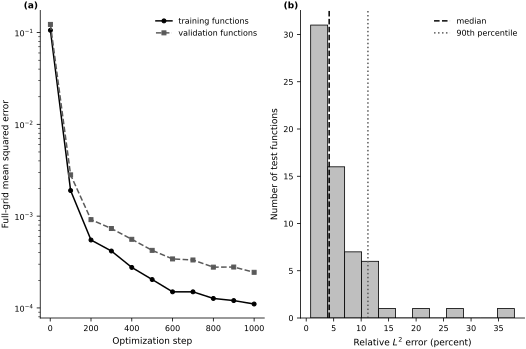

In [8]:
test_predictions = predict_operator(
    model, a_test.astype(np.float32), sensor_grid.astype(np.float32)
)
test_mse = np.mean((test_predictions - g_test_functions) ** 2)
relative_errors, squared_errors, target_energies = relative_l2_errors(
    test_predictions, g_test_functions, sensor_grid
)
aggregate_relative_l2 = np.sqrt(squared_errors.sum() / target_energies.sum())

print(f"test grid MSE: {test_mse:.3e}")
print(f"aggregate relative L2 error: {aggregate_relative_l2:.3%}")
print(f"median functionwise relative L2 error: {np.nanmedian(relative_errors):.3%}")
print(f"90th percentile functionwise relative L2 error: {np.nanpercentile(relative_errors, 90):.3%}")

fig, axes = new_figure("full_standard", nrows=1, ncols=2, constrained=True)
axes[0].semilogy(
    history["step"], history["train_mse"],
    color="black", marker="o", label="training functions"
)
axes[0].semilogy(
    history["step"], history["validation_mse"],
    color="0.35", linestyle="--", marker="s", label="validation functions"
)
axes[0].set_xlabel("Optimization step")
axes[0].set_ylabel("Full-grid mean squared error")
axes[0].legend()

axes[1].hist(
    100.0 * relative_errors[np.isfinite(relative_errors)],
    bins=12,
    color="0.75",
    edgecolor="black",
)
axes[1].axvline(
    100.0 * np.nanmedian(relative_errors),
    color="black", linestyle="--", label="median"
)
axes[1].axvline(
    100.0 * np.nanpercentile(relative_errors, 90),
    color="0.35", linestyle=":", label="90th percentile"
)
axes[1].set_xlabel(r"Relative $L^2$ error (percent)")
axes[1].set_ylabel("Number of test functions")
axes[1].legend()
label_panels(axes, x=-0.01, y=1.0, ha="right", va="bottom")
finalize_axes(axes);

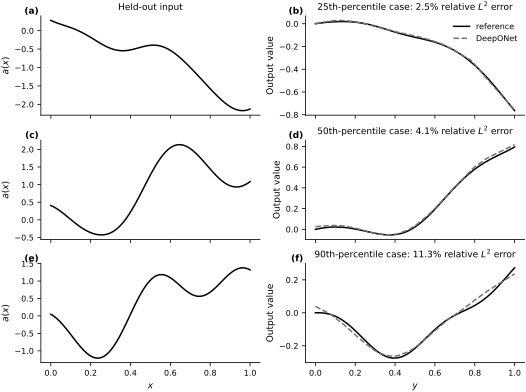

In [9]:
percentile_levels = np.array([25.0, 50.0, 90.0])
percentile_errors = np.nanpercentile(relative_errors, percentile_levels)
selected = [
    int(np.nanargmin(np.abs(relative_errors - target_error)))
    for target_error in percentile_errors
]

fig, axes = new_figure(
    "full_tall", nrows=3, ncols=2, sharex=True, constrained=True
)
for row, (percentile, idx) in enumerate(zip(percentile_levels, selected)):
    axes[row, 0].plot(sensor_grid, a_test[idx], color="black")
    axes[row, 0].set_ylabel(r"$a(x)$")

    axes[row, 1].plot(
        sensor_grid, g_test_functions[idx], color="black", label="reference"
    )
    axes[row, 1].plot(
        sensor_grid, test_predictions[idx],
        color="0.45", linestyle="--", label="DeepONet"
    )
    axes[row, 1].set_ylabel("Output value")
    axes[row, 1].set_title(
        f"{percentile:.0f}th-percentile case: "
        f"{relative_errors[idx]:.1%} relative $L^2$ error"
    )

axes[0, 0].set_title("Held-out input")
axes[0, 1].legend()
axes[-1, 0].set_xlabel(r"$x$")
axes[-1, 1].set_xlabel(r"$y$")
label_panels(axes, x=-0.01, y=1.0, ha="right", va="bottom")
finalize_axes(axes);

## Results and limitations

The learning curves compare full-grid errors on independent training and validation functions. The histogram and percentile cases then summarize the untouched test set, rather than displaying only favorable examples. The companion notebook reports both pointwise mean squared error and quadrature-weighted relative $L^2$ errors.

The aggregate relative $L^2$ error is $3.45\%$. The median functionwise error is $4.18\%$, while the $90$th percentile is $11.23\%$. The spread is a reminder that one average does not describe performance on every input.

The conclusions are deliberately narrow. The test functions come from the same Gaussian random field as the training functions, and every target is evaluated on the same $100$-point grid. The experiment therefore probes held-out-input generalization for one discretized smoothing operator. It does not test a new input distribution, unseen sensor geometry, a different resolution, or convergence to the continuum operator.

The companion notebook summarized in Section {ref}`sec-hup-op-03-fno` studies a discretized PDE solution operator with a Fourier neural operator {cite:p}`li2021fourier`. That architecture replaces the branch--trunk factorization with learned spectral convolutions.

## Exercises

1. Use validation error to compare `num_steps = 600`, `1_000`, and `3_000` in the companion notebook. Choose one setting before evaluating a fresh test set, and report whether the added computation is worthwhile.
2. Hold a finer integration-and-query grid and the sampled functions fixed, then subsample $50$, $100$, and $200$ branch sensors. Explain why changing the sensor count changes both the available information and the number of branch-network parameters.
3. Increase `num_train_functions` while holding the validation and test functions fixed. Compare the effect of more input functions with the effect of more query points per function.
4. Vary `latent_dim` and the hidden-layer width separately. Use parameter counts and validation error to distinguish underfitting from diminishing returns.
5. Train at length scale $0.2$ and test on shorter length scales. Treat this as out-of-distribution evaluation, not as another sample from the training law.
6. Separate the sensor grid from the query grid and evaluate at query locations not used to form the training triples. Which additional generalization claim does this experiment probe?